<a href="https://colab.research.google.com/github/sanganalasya-hash/Data-Science/blob/main/AP_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb

In [ ]:
!pip install bambi

# Part A

In [4]:
econ = pd.read_csv('https://raw.githubusercontent.com/sanganalasya-hash/Data-Science/refs/heads/main/hemline_economy_clean_main.csv')

In [ ]:
econ

,Year,Hemline,CCI,Unemployment
0,1973,8.000000,100.764513,4.858333
1,1974,8.000000,98.906894,5.641667
2,1975,6.642857,99.482825,8.475000
3,1976,8.000000,100.924358,7.700000
4,1977,7.318182,101.122617,7.050000
5,1978,7.375000,101.456783,6.066667
6,1979,7.520000,100.250817,5.850000
7,1980,6.833333,99.028260,7.175000
8,1981,6.950000,98.791209,7.616667
9,1982,6.950000,98.872897,9.708333


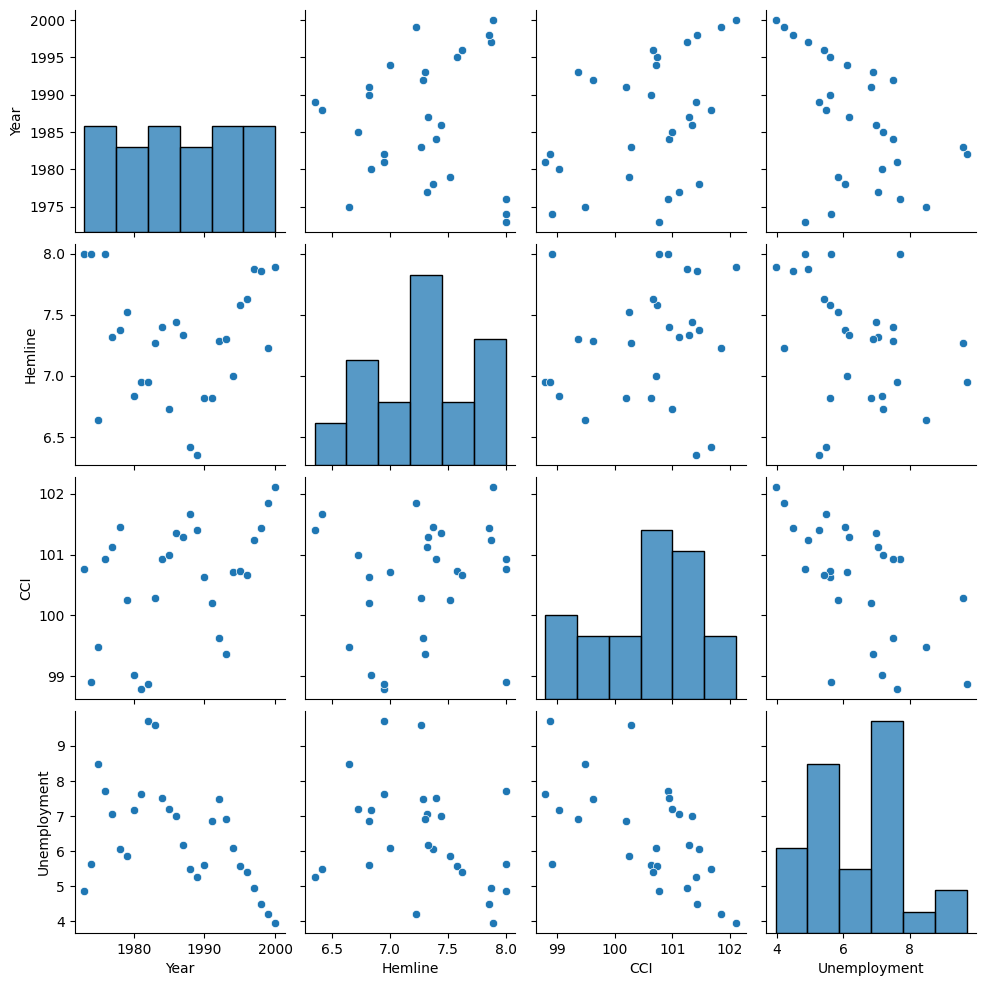

In [ ]:
sns.pairplot(econ)

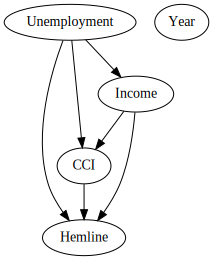

In [ ]:
dag_econ = gv.Digraph(comment='bballh_dag') #bball hierarchy

dag_econ.node('H', 'Hemline')
dag_econ.node('Y','Year')
dag_econ.node('C','CCI')
dag_econ.node('U','Unemployment')
dag_econ.node('I','Income')

dag_econ.edges(['CH','UH', 'IH',  'UC', 'IC', 'UI'])

dag_econ

## Model 1

In [ ]:
#define the model
model_1 = bmb.Model("`Hemline` ~ `CCI` + `Year`", data=econ)
#fit the model, generating posterior predictive samples directly
idata_1 = model_1.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [91]:
pp_idata_1 = model_1.predict(idata_1, kind='response')

<Axes: xlabel='Hemline'>

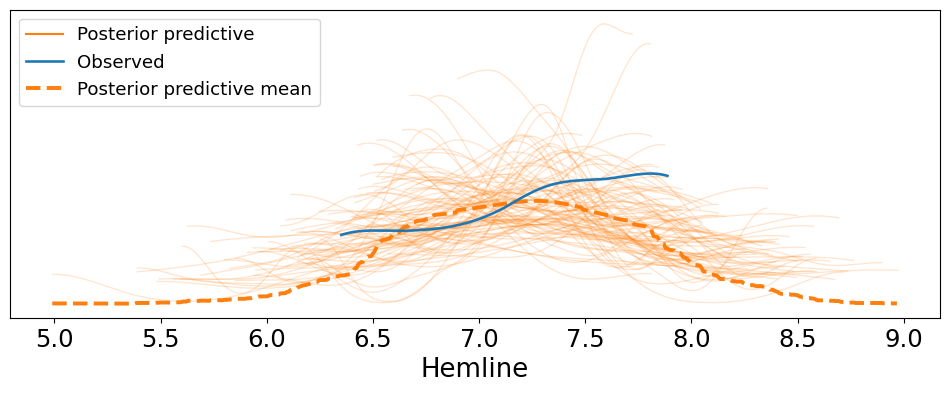

In [92]:
az.plot_ppc(idata_1, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

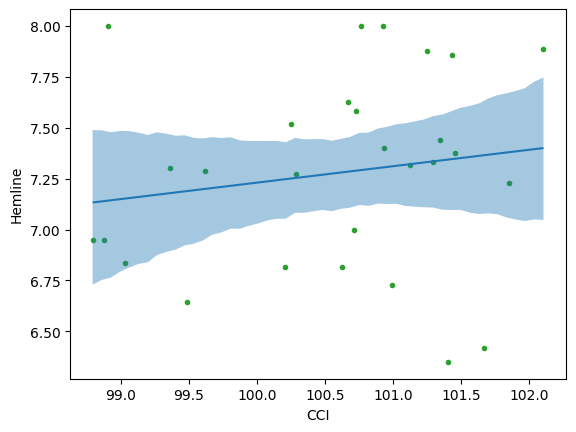

In [9]:
bmb.interpret.plot_predictions(model_1, idata_1, "CCI")
plt.plot(econ.CCI, econ.Hemline, "C2.", zorder=-3)

## Model 2

In [ ]:
#define the model
model_2 = bmb.Model("`Hemline` ~ `Unemployment` + `Year`", data=econ)
#fit the model
idata_2 = model_2.fit(idata_kwargs={'log_likelihood': True})

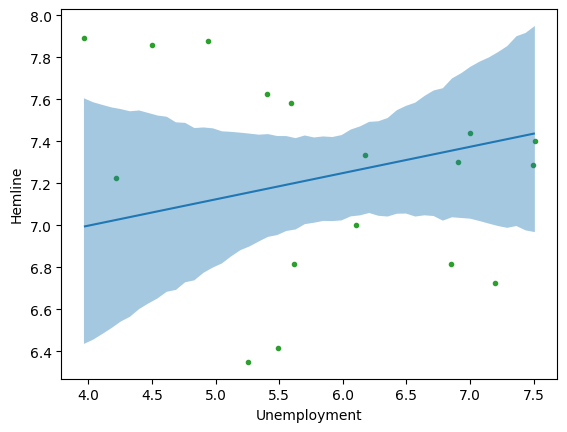

In [94]:
bmb.interpret.plot_predictions(model_2, idata_2, "Unemployment")
plt.plot(econ.Unemployment, econ.Hemline, "C2.", zorder=-3)

In [95]:
pp_idata_2 = model_2.predict(idata_2, kind='response')

<Axes: xlabel='Hemline'>

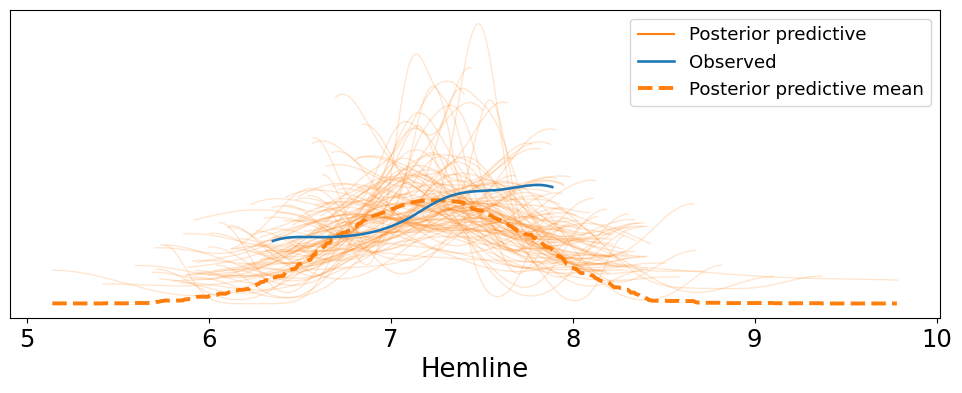

In [96]:
az.plot_ppc(idata_2, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 3

In [ ]:
#define the model
model_3 = bmb.Model("`Hemline` ~ `Unemployment` + `CCI` + `Year`", data=econ)
#fit the model
idata_3 = model_3.fit(idata_kwargs={'log_likelihood': True})

In [98]:
pp_idata_3 = model_3.predict(idata_3, kind='response')

<Axes: xlabel='Hemline'>

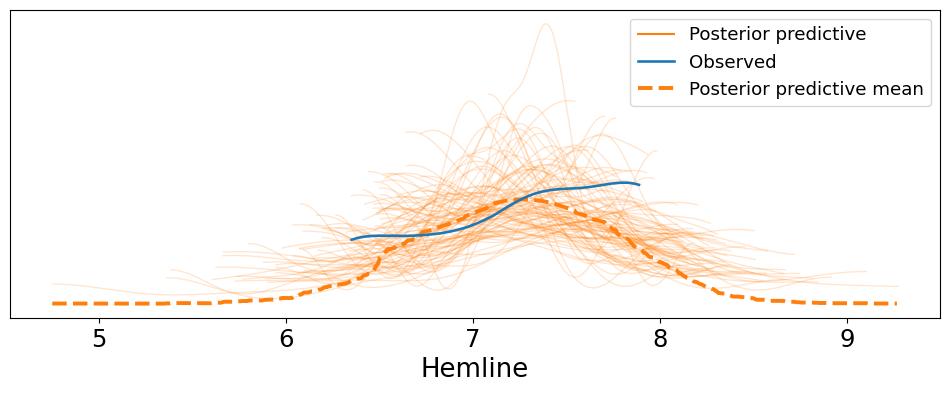

In [99]:
az.plot_ppc(idata_3, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 4

In [ ]:
# Create the interaction term explicitly
econ['CCI_Unemployment_interaction'] = econ['CCI'] * econ['Unemployment']

#define the model using the new interaction term
model_4 = bmb.Model("`Hemline` ~ `CCI` + `Unemployment` + `CCI_Unemployment_interaction` + `Year`", data=econ)
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_4 = model_4.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

In [132]:
pp_idata_4 = model_4.predict(idata_4, kind='response')

<Axes: xlabel='Hemline'>

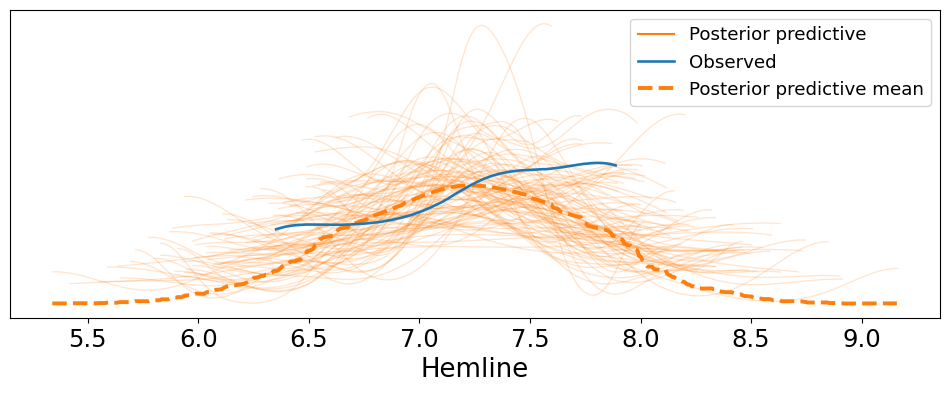

In [133]:
az.plot_ppc(idata_4, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Compare A

In [127]:
cmp_df = az.compare({
    'CCI + Year': idata_1,
    'Unemployment + Year': idata_2,
    'CCI + Unemployment + Year': idata_3,
    'CCI + Unemployment + Year + CCI:Unemployment': idata_4,
})

display(cmp_df)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
CCI + Unemployment + Year,0,-10.280313,3.526771,0.000000,1.000000e+00,1.246166,0.000000,False,log
CCI + Unemployment + Year + CCI:Unemployment,1,-10.376282,3.535851,0.095969,0.000000e+00,1.210635,0.129279,False,log
Unemployment + Year,2,-11.627109,3.448831,1.346796,1.004448e-16,1.689284,1.183532,True,log
CCI + Year,3,-11.971902,3.098930,1.691589,0.000000e+00,1.973889,1.475827,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

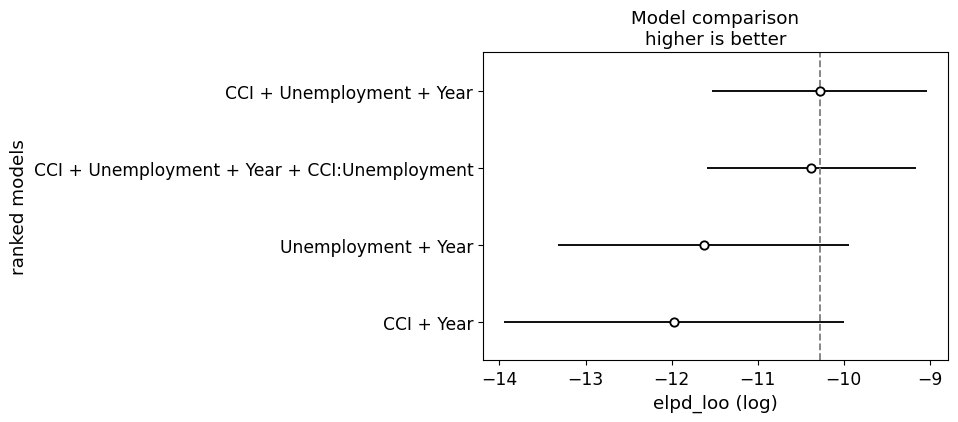

In [128]:
az.plot_compare(cmp_df)

# Part B

In [34]:
econ_1 = pd.read_csv('https://raw.githubusercontent.com/sanganalasya-hash/Data-Science/refs/heads/main/hemline_economy_clean_with_income.csv')

In [35]:
econ_1

,Year,Hemline,CCI,Unemployment,Income
0,1984,7.400000,100.936183,7.508333,60420
1,1985,6.727273,100.996592,7.191667,61570
2,1986,7.437500,101.349350,7.000000,63850
3,1987,7.333333,101.296958,6.175000,64650
4,1988,6.416667,101.666342,5.491667,65130
5,1989,6.350000,101.402525,5.258333,66240
6,1990,6.818182,100.627461,5.616667,65440
7,1991,6.818182,100.204170,6.850000,63530
8,1992,7.285714,99.621260,7.491667,63010
9,1993,7.300000,99.359034,6.908333,62700


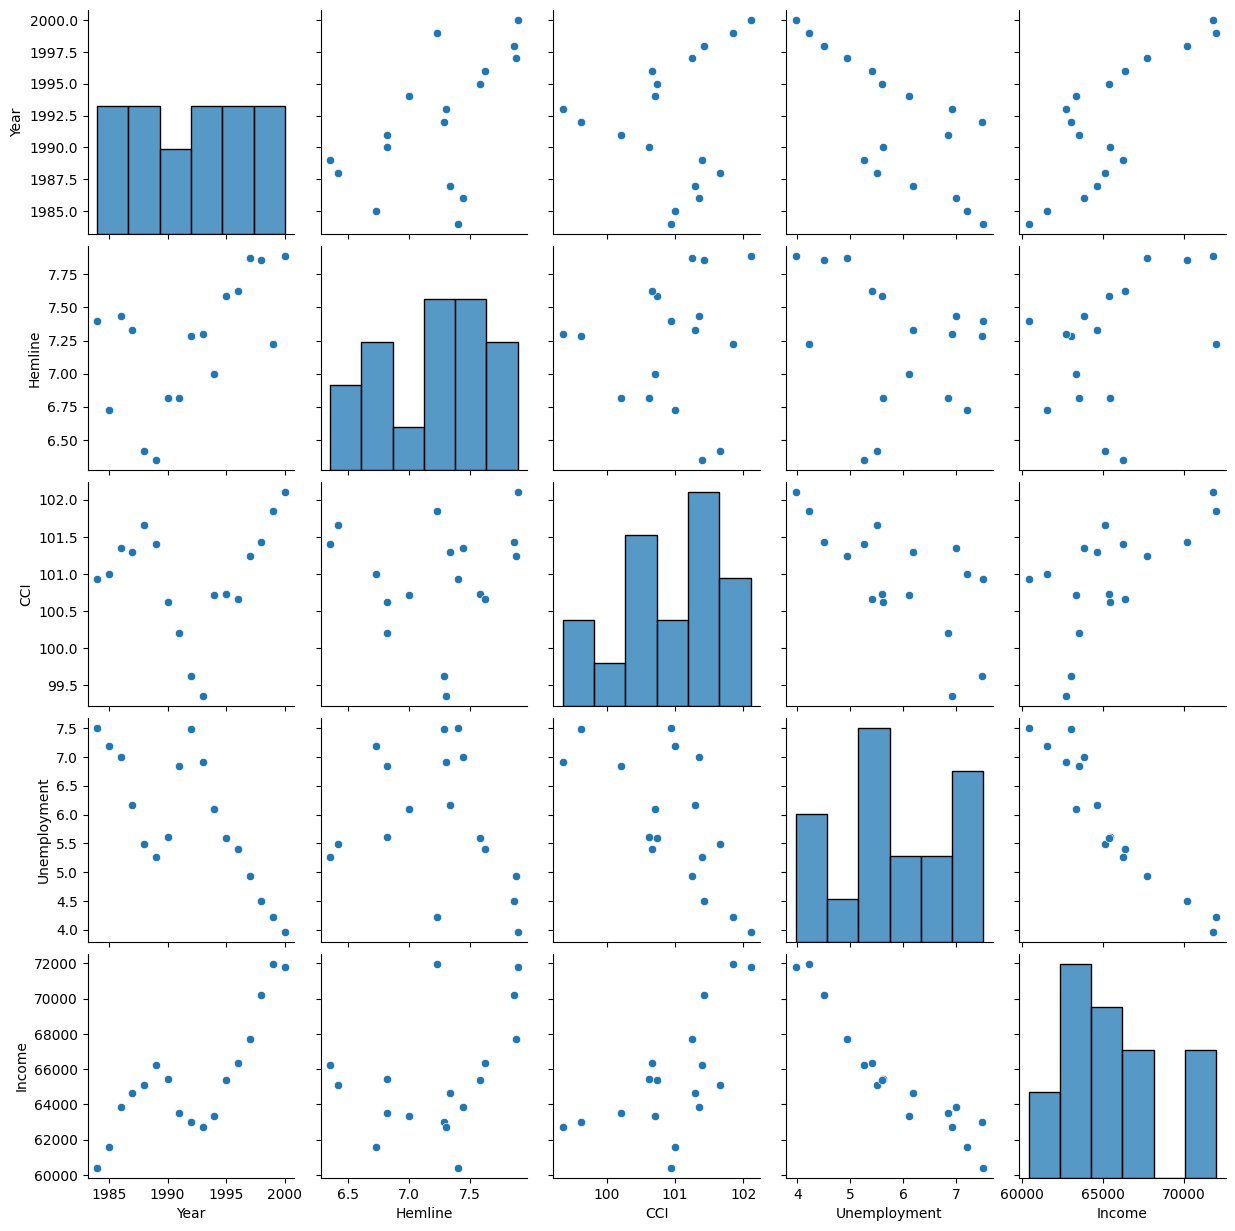

In [36]:
sns.pairplot(econ_1)

## Model 1b

In [ ]:
#define the model
model_1b = bmb.Model("`Hemline` ~ `CCI` + `Year`", data=econ_1)
#fit the model, generating posterior predictive samples directly
idata_1b = model_1b.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [103]:
pp_idata_1b = model_1b.predict(idata_1b, kind='response')

<Axes: xlabel='Hemline'>

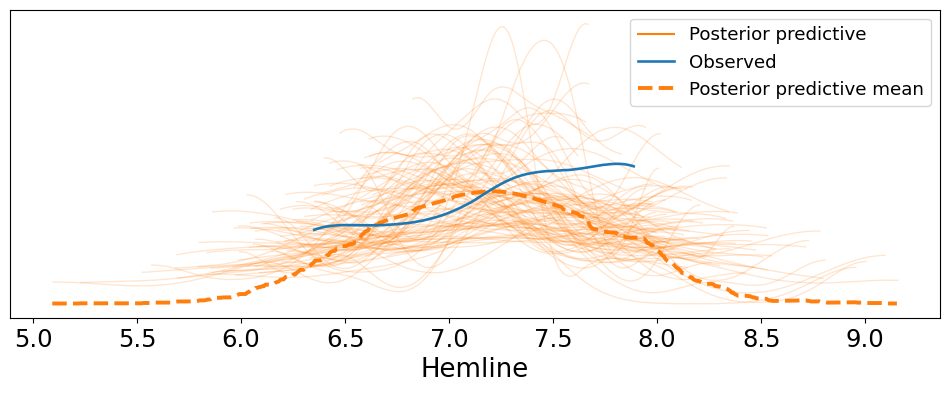

In [104]:
az.plot_ppc(idata_1b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 2b

In [ ]:
#define the model
model_2b = bmb.Model("`Hemline` ~ `Unemployment` + `Year`", data=econ_1)
#fit the model
idata_2b = model_2b.fit(idata_kwargs={'log_likelihood': True})

In [106]:
pp_idata_2b = model_2b.predict(idata_2b, kind='response')

<Axes: xlabel='Hemline'>

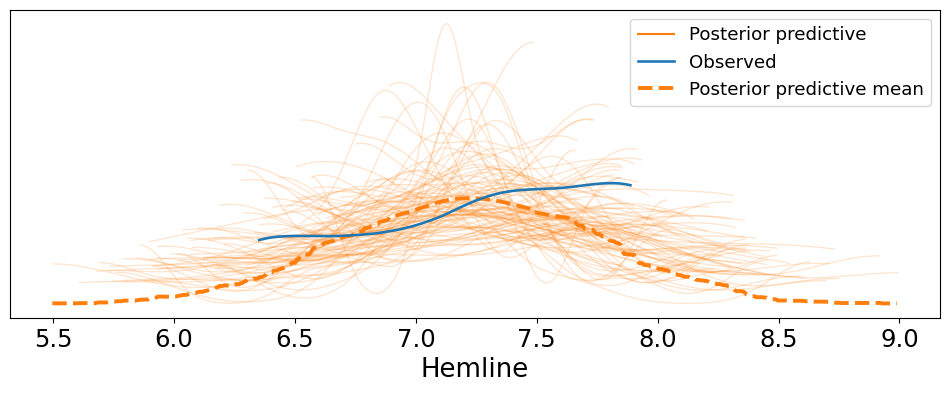

In [107]:
az.plot_ppc(idata_2b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 3b

In [ ]:
#define the model
model_3b = bmb.Model("`Hemline` ~ `Unemployment` + `CCI` + `Year`", data=econ_1)
#fit the model
idata_3b = model_3b.fit(idata_kwargs={'log_likelihood': True})

In [109]:
pp_idata_3b = model_3b.predict(idata_3b, kind='response')

In [ ]:
az.plot_ppc(idata_3b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 4b

In [ ]:
# Create the interaction term explicitly in econ_1
econ_1['CCI_Unemployment_interaction'] = econ_1['CCI'] * econ_1['Unemployment']

#define the model using the new interaction term
model_4b = bmb.Model("`Hemline` ~ `CCI` + `Unemployment` + `CCI_Unemployment_interaction` + `Year`", data=econ_1)
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_4b = model_4b.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

In [136]:
pp_idata_4b = model_4b.predict(idata_4b, kind='response')

<Axes: xlabel='Hemline'>

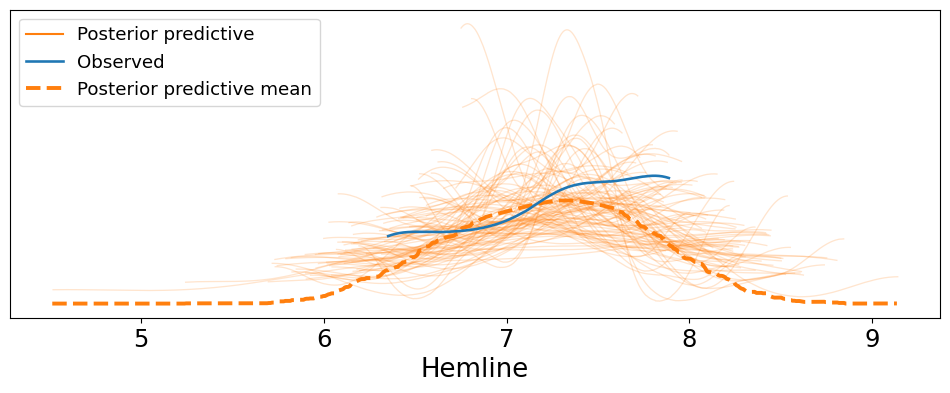

In [137]:
az.plot_ppc(idata_4b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 5

In [ ]:
#define the model
model_5 = bmb.Model("`Hemline` ~ `Unemployment` + `Income` + `Year`", data=econ_1)
#fit the model, generating posterior predictive samples directly
idata_5 = model_5.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [139]:
pp_idata_5 = model_5.predict(idata_5, kind='response')

<Axes: xlabel='Hemline'>

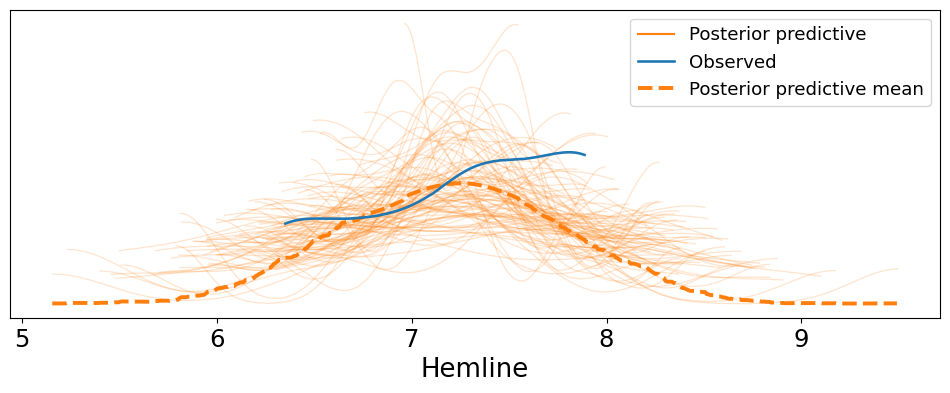

In [141]:
az.plot_ppc(idata_5, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 6

In [ ]:
#define the model
model_6 = bmb.Model("`Hemline` ~ `Income` + `Year`", data=econ_1)
#fit the model, generating posterior predictive samples directly
idata_6 = model_6.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [143]:
pp_idata_6 = model_6.predict(idata_6, kind='response')

<Axes: xlabel='Hemline'>

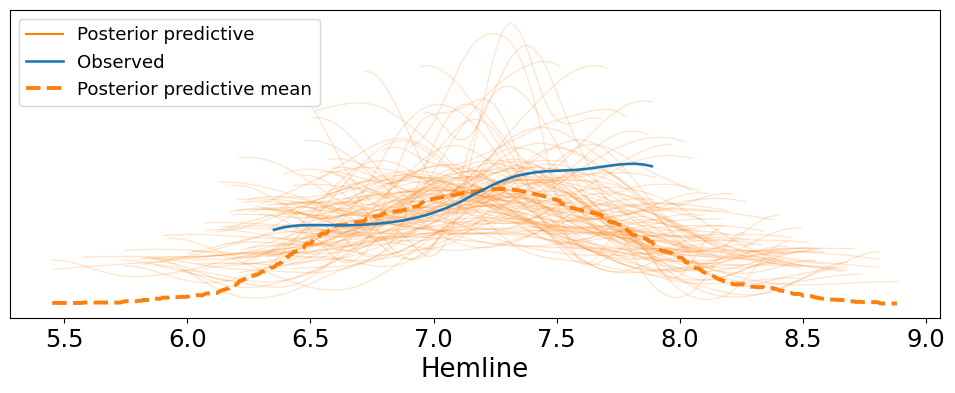

In [144]:
az.plot_ppc(idata_6, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 7

In [ ]:
#define the model
model_7 = bmb.Model("`Hemline` ~ `Unemployment` + `Income` + `CCI` + `Year`", data=econ_1)
#fit the model, generating posterior predictive samples directly
idata_7 = model_7.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [146]:
pp_idata_7 = model_7.predict(idata_7, kind='response')

<Axes: xlabel='Hemline'>

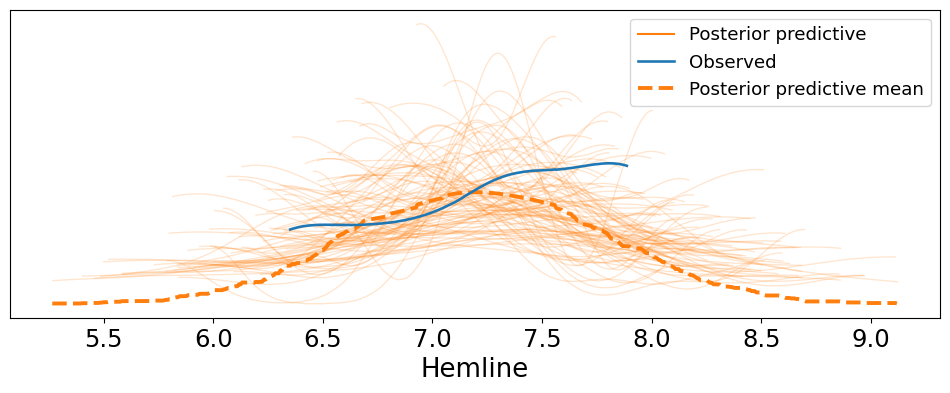

In [118]:
az.plot_ppc(idata_7, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 8


In [ ]:
#define the model
model_8 = bmb.Model("Hemline ~ Income + Unemployment + Income:Unemployment + Year", data=econ_1)
#fit the model, generating posterior predictive samples directly
idata_8 = model_8.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [148]:
pp_idata_8 = model_8.predict(idata_8, kind='response')

<Axes: xlabel='Hemline'>

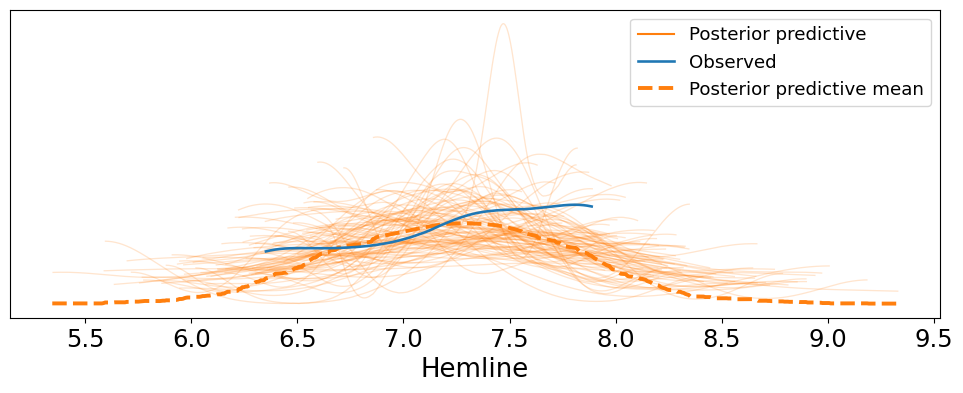

In [149]:
az.plot_ppc(idata_8, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Compare B

In [150]:
cmp_df_1 = az.compare({
       'CCI': idata_1b,
    'Unemployment + Year': idata_2b,
    'CCI + Unemployment + Year': idata_3b,
    'CCI + Unemployment + Year + CCI:Unemployment': idata_4b,
    'Income + Unemployment + Year': idata_5,
    'Income + Year': idata_6,
    'CCI + Unemployment + Income + Year': idata_7,
    'Income + Unemployment + Year + Income:Unemployment': idata_8,
})

display(cmp_df_1)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
CCI + Unemployment + Year + CCI:Unemployment,0,-10.156855,3.373230,0.000000,1.000000e+00,1.142265,0.000000,False,log
CCI + Unemployment + Year,1,-10.284048,3.474683,0.127193,0.000000e+00,1.213699,0.117802,True,log
Unemployment + Year,2,-11.317640,3.125107,1.160785,0.000000e+00,1.589021,1.152643,False,log
CCI + Unemployment + Income + Year,3,-11.800215,4.706465,1.643360,9.734408e-16,1.458084,0.552916,False,log
Income + Year,4,-11.972364,3.243003,1.815509,0.000000e+00,1.826964,1.355933,False,log
CCI,5,-12.050815,3.235583,1.893960,0.000000e+00,2.030995,1.601457,False,log
Income + Unemployment + Year,6,-12.274538,4.235808,2.117683,0.000000e+00,1.684212,1.136856,True,log
Income + Unemployment + Year + Income:Unemployment,7,-12.459106,4.278932,2.302252,0.000000e+00,1.677684,1.124906,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

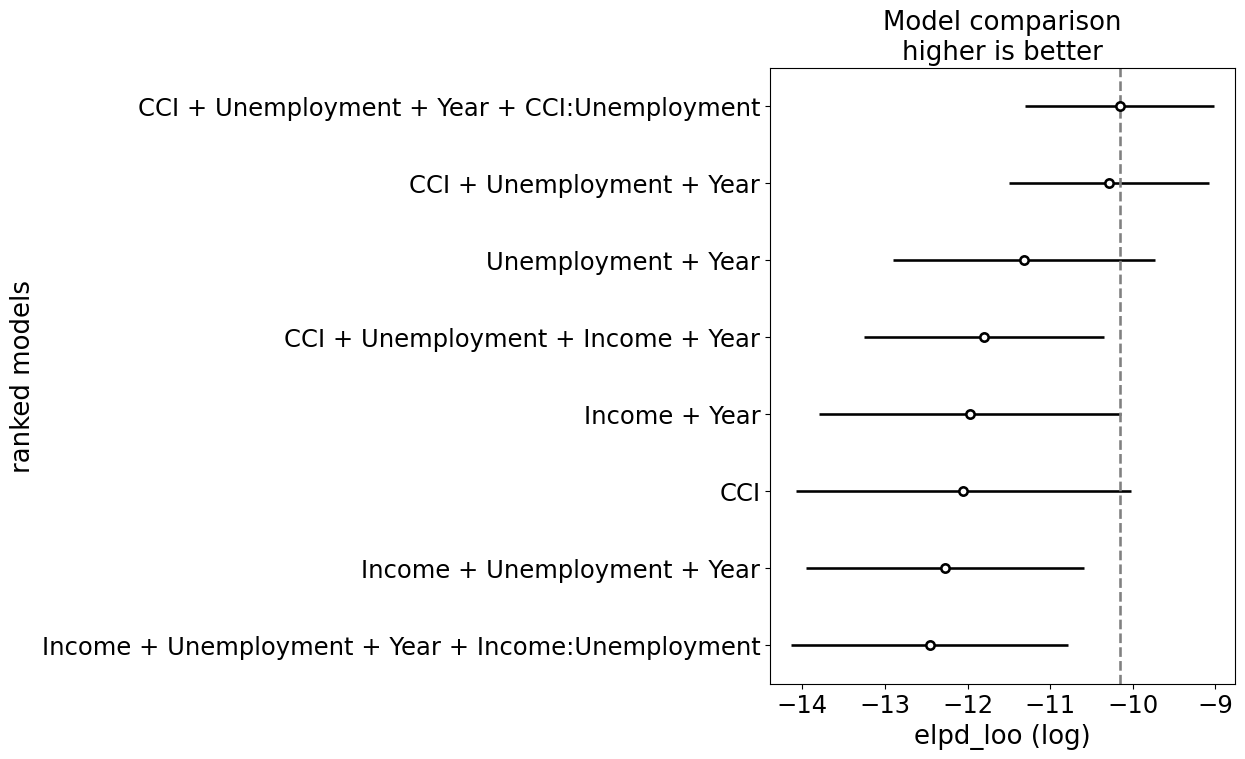

In [151]:
az.plot_compare(cmp_df_1)